# 14 — KITTI LiDAR-to-camera projection

This notebook validates the geometric bridge required for camera–LiDAR fusion.

For each LiDAR point, it:

1. transforms LiDAR coordinates into the rectified camera frame;
2. projects the point into the left color image using `P2`;
3. rejects points behind the camera or outside the actual image;
4. preserves the original LiDAR point index;
5. samples the corresponding RGB pixel.

The final arrays `visible_lidar_points` and `rgb` are aligned row by row and can be aggregated into a camera-derived BEV.


In [92]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset.kitti_dataset import KittiDataset

dataset = KittiDataset(
    root=PROJECT_ROOT / "data" / "KITTI",
    split="training",
    load_images=True,
)

sample = dataset[220]
points = sample["points"]
image = sample["image"]
calib = sample["calib"]

print("Sample ID:", sample["id"])
print("LiDAR shape:", points.shape)
print("Image shape:", image.shape)
print("Image dtype:", image.dtype)
print("Calibration keys:", calib.keys())
print("Labels:", len(sample["labels"]))

assert points.ndim == 2 and points.shape[1] == 4
assert image.ndim == 3 and image.shape[2] == 3


Sample ID: 000220
LiDAR shape: (118043, 4)
Image shape: (375, 1242, 3)
Image dtype: uint8
Calibration keys: dict_keys(['p2', 'r0_rect', 'tr_velo_to_cam'])
Labels: 8


In [93]:
def transformation_to_rectified(
    xyz,
    tr_velo_to_cam,
    r0_rect,
):
    """Transform LiDAR XYZ points into rectified-camera coordinates."""
    xyz = np.asarray(xyz, dtype=np.float64)
    tr_velo_to_cam = np.asarray(
        tr_velo_to_cam,
        dtype=np.float64,
    )
    r0_rect = np.asarray(
        r0_rect,
        dtype=np.float64,
    )

    if xyz.ndim != 2 or xyz.shape[1] != 3:
        raise ValueError(
            f"xyz must have shape (N, 3), got {xyz.shape}"
        )
    if tr_velo_to_cam.shape != (3, 4):
        raise ValueError(
            "tr_velo_to_cam must have shape (3, 4)"
        )
    if r0_rect.shape != (3, 3):
        raise ValueError(
            "r0_rect must have shape (3, 3)"
        )
    if not np.isfinite(xyz).all():
        raise ValueError(
            "xyz must contain only finite values"
        )
    if (
        not np.isfinite(tr_velo_to_cam).all()
        or not np.isfinite(r0_rect).all()
    ):
        raise ValueError(
            "calibration matrices must be finite"
        )

    xyz_homogeneous = np.column_stack(
        [
            xyz,
            np.ones(len(xyz), dtype=np.float64),
        ]
    )

    camera_xyz = (
        tr_velo_to_cam
        @ xyz_homogeneous.T
    ).T

    rectified_xyz = (
        r0_rect
        @ camera_xyz.T
    ).T

    return rectified_xyz


def project_rectified_to_image(
    rectified_xyz,
    p2,
    image_shape,
):
    """
    Project rectified-camera points into image_2.

    Returns
    -------
    pixels:
        Valid floating-point [u, v] coordinates, shape (M, 2).

    valid_indices:
        Indices into the original LiDAR/rectified point array,
        shape (M,).

    depths:
        Positive rectified-camera z coordinates, shape (M,).
    """
    rectified_xyz = np.asarray(
        rectified_xyz,
        dtype=np.float64,
    )
    p2 = np.asarray(p2, dtype=np.float64)

    if (
        rectified_xyz.ndim != 2
        or rectified_xyz.shape[1] != 3
    ):
        raise ValueError(
            "rectified_xyz must have shape (N, 3)"
        )
    if p2.shape != (3, 4):
        raise ValueError("p2 must have shape (3, 4)")
    if not np.isfinite(p2).all():
        raise ValueError("p2 must contain finite values")
    if len(image_shape) < 2:
        raise ValueError(
            "image_shape must contain height and width"
        )

    image_height = int(image_shape[0])
    image_width = int(image_shape[1])

    if image_height <= 0 or image_width <= 0:
        raise ValueError(
            "image dimensions must be positive"
        )

    original_indices = np.arange(
        len(rectified_xyz),
        dtype=np.int64,
    )

    in_front = (
        np.isfinite(rectified_xyz).all(axis=1)
        & (rectified_xyz[:, 2] > 0)
    )

    visible_points = rectified_xyz[in_front]
    visible_indices = original_indices[in_front]

    visible_homogeneous = np.column_stack(
        [
            visible_points,
            np.ones(
                len(visible_points),
                dtype=np.float64,
            ),
        ]
    )

    image_homogeneous = (
        p2
        @ visible_homogeneous.T
    ).T

    valid_projection = (
        np.isfinite(image_homogeneous).all(axis=1)
        & (image_homogeneous[:, 2] > 0)
    )

    image_homogeneous = image_homogeneous[
        valid_projection
    ]
    visible_points = visible_points[valid_projection]
    visible_indices = visible_indices[valid_projection]

    projected_depth = image_homogeneous[:, 2]
    u = image_homogeneous[:, 0] / projected_depth
    v = image_homogeneous[:, 1] / projected_depth

    inside_image = (
        np.isfinite(u)
        & np.isfinite(v)
        & (u >= 0)
        & (u < image_width)
        & (v >= 0)
        & (v < image_height)
    )

    pixels = np.column_stack(
        [
            u[inside_image],
            v[inside_image],
        ]
    )
    valid_indices = visible_indices[inside_image]
    depths = visible_points[inside_image, 2]

    return (
        pixels.astype(np.float32),
        valid_indices.astype(np.int64),
        depths.astype(np.float32),
    )


def project_lidar_to_image(
    points,
    calibration,
    image_shape,
):
    """Convenience wrapper for the complete LiDAR-to-image transform."""
    if not isinstance(calibration, dict):
        raise TypeError("calibration must be a dictionary")

    required = {
        "tr_velo_to_cam",
        "r0_rect",
        "p2",
    }
    missing = required.difference(calibration)

    if missing:
        raise KeyError(
            f"missing calibration keys: {sorted(missing)}"
        )

    points = np.asarray(points)

    if points.ndim != 2 or points.shape[1] < 3:
        raise ValueError(
            "points must have shape (N, 3) or (N, 4)"
        )

    rectified_xyz = transformation_to_rectified(
        points[:, :3],
        calibration["tr_velo_to_cam"],
        calibration["r0_rect"],
    )

    return project_rectified_to_image(
        rectified_xyz,
        calibration["p2"],
        image_shape,
    )


In [94]:
pixels, valid_indices, depths = project_lidar_to_image(
    points,
    calib,
    image.shape,
)

visible_lidar_points = points[valid_indices]

print("Original LiDAR points:", len(points))
print("Projected points inside image:", len(pixels))
print("Pixels shape:", pixels.shape)
print("Valid indices shape:", valid_indices.shape)
print("Depths shape:", depths.shape)
print("Visible LiDAR shape:", visible_lidar_points.shape)

assert pixels.shape == (len(valid_indices), 2)
assert depths.shape == (len(valid_indices),)
assert visible_lidar_points.shape == (
    len(valid_indices),
    4,
)
assert np.all(depths > 0)
assert np.all(pixels[:, 0] >= 0)
assert np.all(pixels[:, 0] < image.shape[1])
assert np.all(pixels[:, 1] >= 0)
assert np.all(pixels[:, 1] < image.shape[0])


Original LiDAR points: 118043
Projected points inside image: 18634
Pixels shape: (18634, 2)
Valid indices shape: (18634,)
Depths shape: (18634,)
Visible LiDAR shape: (18634, 4)


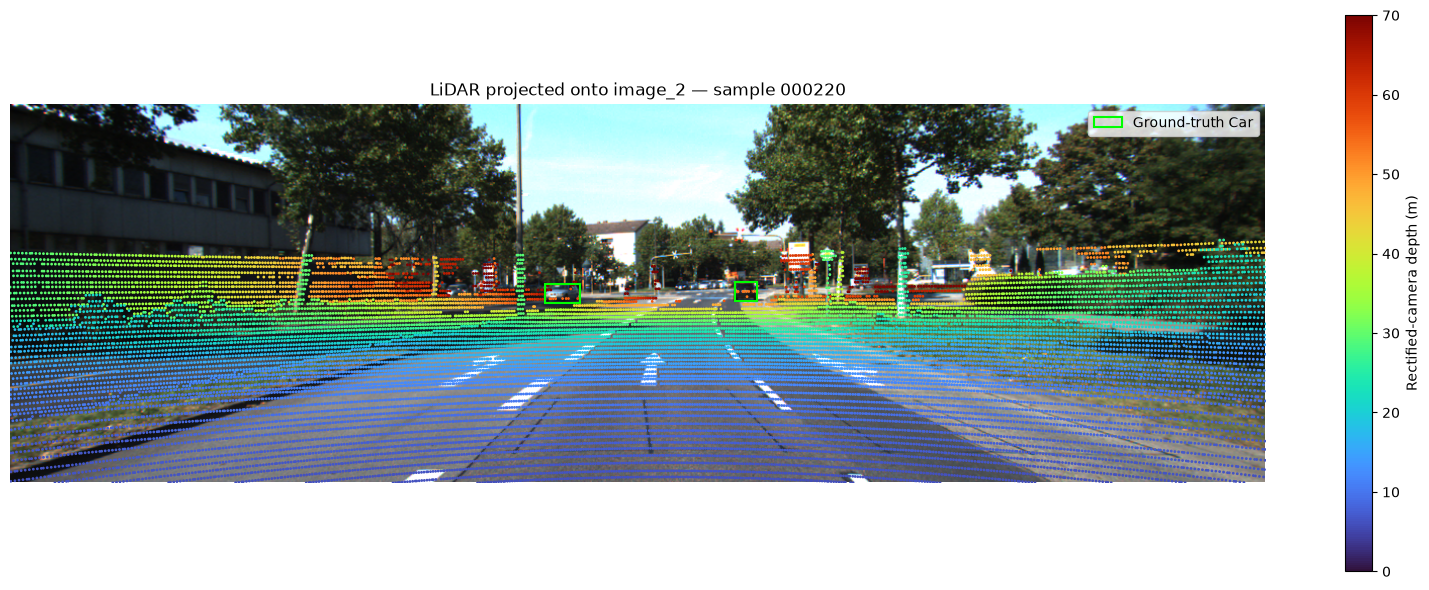

In [95]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.imshow(image)

scatter = ax.scatter(
    pixels[:, 0],
    pixels[:, 1],
    c=depths,
    s=1,
    cmap="turbo",
    vmin=0,
    vmax=70,
)

# KITTI label_2 bounding boxes are defined in image_2 pixels.
for label_index, label in enumerate(sample["labels"]):
    if label["type"] != "Car":
        continue

    x1, y1, x2, y2 = label["bbox"]
    rectangle = Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        edgecolor="lime",
        linewidth=1.5,
        label=(
            "Ground-truth Car"
            if label_index == 0
            else None
        ),
    )
    ax.add_patch(rectangle)

ax.set_xlim(0, image.shape[1])
ax.set_ylim(image.shape[0], 0)
ax.set_title(
    f"LiDAR projected onto image_2 — sample {sample['id']}"
)
ax.axis("off")

fig.colorbar(
    scatter,
    ax=ax,
    label="Rectified-camera depth (m)",
)

handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(loc="upper right")

fig.tight_layout()
plt.show()


In [96]:
# Nearest-pixel RGB sampling for the fusion prototype.
pixel_u = np.rint(
    pixels[:, 0]
).astype(np.int64)

pixel_v = np.rint(
    pixels[:, 1]
).astype(np.int64)

# Rounding can move an edge coordinate by one pixel.
pixel_u = np.clip(
    pixel_u,
    0,
    image.shape[1] - 1,
)
pixel_v = np.clip(
    pixel_v,
    0,
    image.shape[0] - 1,
)

rgb = (
    image[pixel_v, pixel_u]
    .astype(np.float32)
    / 255.0
)

fused_points = np.concatenate(
    [
        visible_lidar_points,
        rgb,
    ],
    axis=1,
)

print("Visible LiDAR points:", visible_lidar_points.shape)
print("Normalized RGB:", rgb.shape)
print("Fused point features:", fused_points.shape)
print(
    "Columns: x, y, z, reflectance, red, green, blue"
)
print("RGB range:", float(rgb.min()), "to", float(rgb.max()))

assert rgb.shape == (len(visible_lidar_points), 3)
assert fused_points.shape == (
    len(visible_lidar_points),
    7,
)
assert np.all((rgb >= 0) & (rgb <= 1))

# Every row now represents one aligned LiDAR/camera observation.
fused_points[:5]


Visible LiDAR points: (18634, 4)
Normalized RGB: (18634, 3)
Fused point features: (18634, 7)
Columns: x, y, z, reflectance, red, green, blue
RGB range: 0.007843137718737125 to 1.0


array([[29.708     ,  4.23      ,  1.224     ,  0.14      ,  0.10980392,
         0.14509805,  0.19215687],
       [29.659     ,  4.318     ,  1.223     ,  0.24      ,  0.10980392,
         0.12941177,  0.14901961],
       [29.502     ,  4.39      ,  1.218     ,  0.        ,  0.1254902 ,
         0.14509805,  0.17254902],
       [29.691     ,  4.466     ,  1.224     ,  0.        ,  0.18039216,
         0.22745098,  0.20392157],
       [54.52      ,  9.895     ,  2.083     ,  0.        ,  0.10980392,
         0.14901961,  0.16862746]], dtype=float32)

## Result

The projection is ready for fusion when the depth-coloured points align with the image surfaces over several different frames.

The important output is:

```text
fused_points[:, 0:4] → x, y, z, reflectance
fused_points[:, 4:7] → normalized R, G, B
```

The next step is to aggregate these aligned point features into the existing `350 × 400` BEV grid and add a camera-visibility channel.


In [97]:
image = sample["image"]  # Already RGB

pixel_x = np.rint(pixels[:, 0]).astype(np.int64)
pixel_y = np.rint(pixels[:, 1]).astype(np.int64)

pixel_x = np.clip(pixel_x, 0, image.shape[1] - 1)
pixel_y = np.clip(pixel_y, 0, image.shape[0] - 1)

point_colours = image[pixel_y, pixel_x]
point_colours = point_colours.astype(np.float32) / 255.0

visible_points = sample["points"][valid_indices]

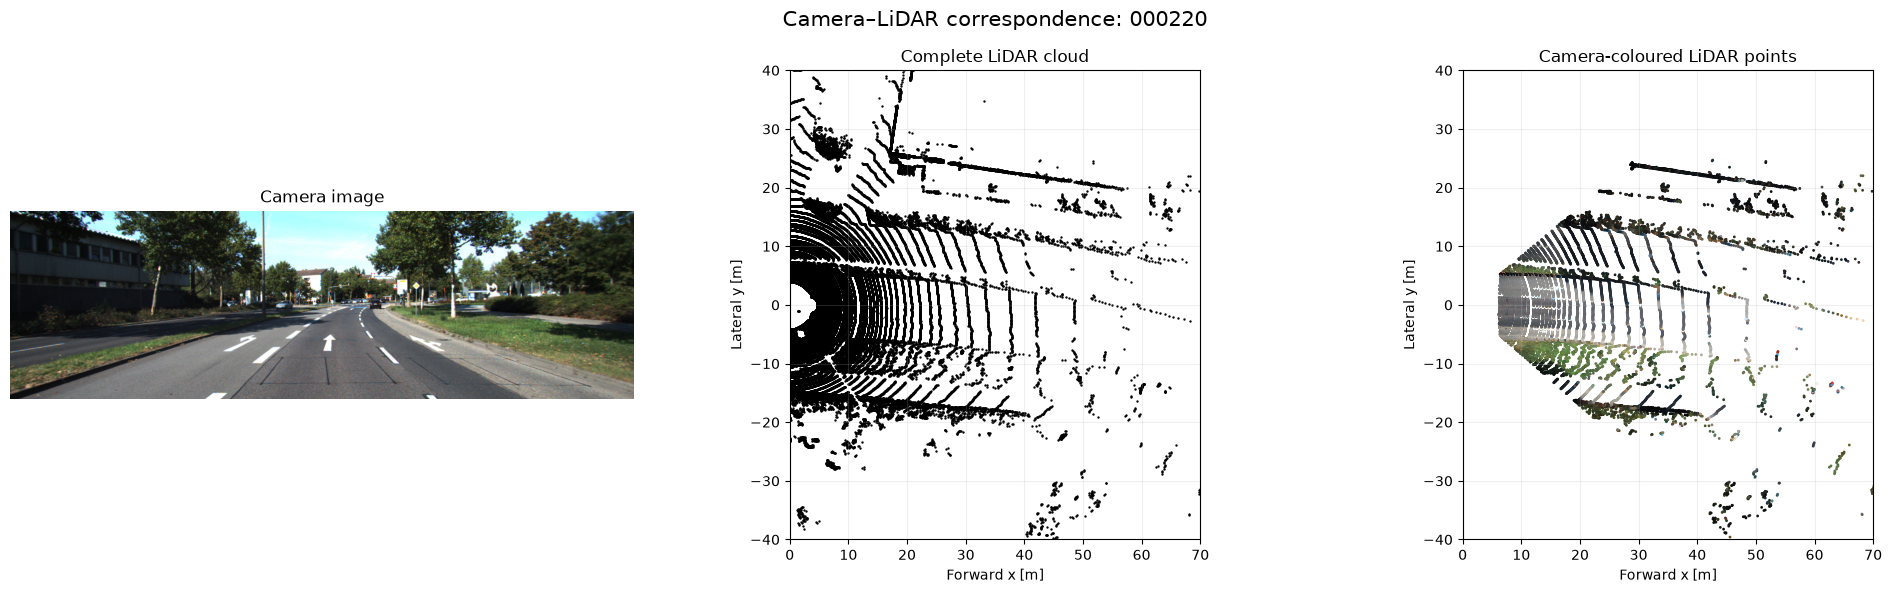

In [98]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6),
)

# 1. RGB camera image
axes[0].imshow(image)
axes[0].set_title("Camera image")
axes[0].axis("off")

# 2. Complete LiDAR cloud
axes[1].scatter(
    points[:, 0],
    points[:, 1],
    c="black",
    s=0.5,
)

axes[1].set_title("Complete LiDAR cloud")
axes[1].set_xlim(0, 70)
axes[1].set_ylim(-40, 40)
axes[1].set_aspect("equal")
axes[1].set_xlabel("Forward x [m]")
axes[1].set_ylabel("Lateral y [m]")
axes[1].grid(alpha=0.2)

# 3. Camera-visible coloured LiDAR points
axes[2].scatter(
    visible_points[:, 0],
    visible_points[:, 1],
    c=point_colours,
    s=1,
)

axes[2].set_title("Camera-coloured LiDAR points")
axes[2].set_xlim(0, 70)
axes[2].set_ylim(-40, 40)
axes[2].set_aspect("equal")
axes[2].set_xlabel("Forward x [m]")
axes[2].set_ylabel("Lateral y [m]")
axes[2].grid(alpha=0.2)

fig.suptitle(
    f"Camera–LiDAR correspondence: {sample['id']}",
    fontsize=15,
)

fig.tight_layout()
plt.show()

In [99]:
import numpy as np

from src.config.constants import (
    BEV_SHAPE,
    POINT_CLOUD_RANGE,
    VOXEL_SIZE,
)


def aggregate_rgb_points_to_bev(fused_points):
    """
    Aggregate camera RGB values attached to LiDAR points into BEV.

    Parameters
    ----------
    fused_points:
        Array with shape (N, 7).

        Columns:
            x, y, z, intensity, red, green, blue

        RGB values are expected to be normalized to [0, 1].

    Returns
    -------
    camera_bev:
        Array with shape (4, 350, 400).

        Channels:
            0: mean red
            1: mean green
            2: mean blue
            3: camera visibility
    """
    fused_points = np.asarray(fused_points)

    if fused_points.ndim != 2 or fused_points.shape[1] != 7:
        raise ValueError(
            "fused_points must have shape (N, 7), "
            f"got {fused_points.shape}"
        )

    if not np.issubdtype(fused_points.dtype, np.number):
        raise TypeError("fused_points must contain numeric values")

    x_min, x_max = POINT_CLOUD_RANGE["x"]
    y_min, y_max = POINT_CLOUD_RANGE["y"]

    # Keep only finite points inside the same region used
    # by the existing LiDAR BEV.
    finite = np.isfinite(fused_points).all(axis=1)

    inside = (
        finite
        & (fused_points[:, 0] >= x_min)
        & (fused_points[:, 0] < x_max)
        & (fused_points[:, 1] >= y_min)
        & (fused_points[:, 1] < y_max)
    )

    points = fused_points[inside].astype(
        np.float32,
        copy=False,
    )

    red_sum = np.zeros(BEV_SHAPE, dtype=np.float32)
    green_sum = np.zeros(BEV_SHAPE, dtype=np.float32)
    blue_sum = np.zeros(BEV_SHAPE, dtype=np.float32)
    point_count = np.zeros(BEV_SHAPE, dtype=np.float32)

    if len(points) == 0:
        return np.stack(
            [
                red_sum,
                green_sum,
                blue_sum,
                point_count,
            ],
            axis=0,
        )

    # Convert metric LiDAR coordinates to BEV cells.
    x_indices = (
        (points[:, 0] - x_min)
        / VOXEL_SIZE["x"]
    ).astype(np.int32)

    y_indices = (
        (points[:, 1] - y_min)
        / VOXEL_SIZE["y"]
    ).astype(np.int32)

    # Accumulate every point's RGB value into its BEV cell.
    np.add.at(
        red_sum,
        (x_indices, y_indices),
        points[:, 4],
    )

    np.add.at(
        green_sum,
        (x_indices, y_indices),
        points[:, 5],
    )

    np.add.at(
        blue_sum,
        (x_indices, y_indices),
        points[:, 6],
    )

    np.add.at(
        point_count,
        (x_indices, y_indices),
        1.0,
    )

    # Cells containing at least one camera-associated point.
    visible = point_count > 0

    red_mean = np.zeros_like(red_sum)
    green_mean = np.zeros_like(green_sum)
    blue_mean = np.zeros_like(blue_sum)

    red_mean[visible] = (
        red_sum[visible] / point_count[visible]
    )

    green_mean[visible] = (
        green_sum[visible] / point_count[visible]
    )

    blue_mean[visible] = (
        blue_sum[visible] / point_count[visible]
    )

    visibility = visible.astype(np.float32)

    camera_bev = np.stack(
        [
            red_mean,
            green_mean,
            blue_mean,
            visibility,
        ],
        axis=0,
    )

    return camera_bev

In [100]:
camera_bev = aggregate_rgb_points_to_bev(
    fused_points
)

print(camera_bev.shape)

(4, 350, 400)


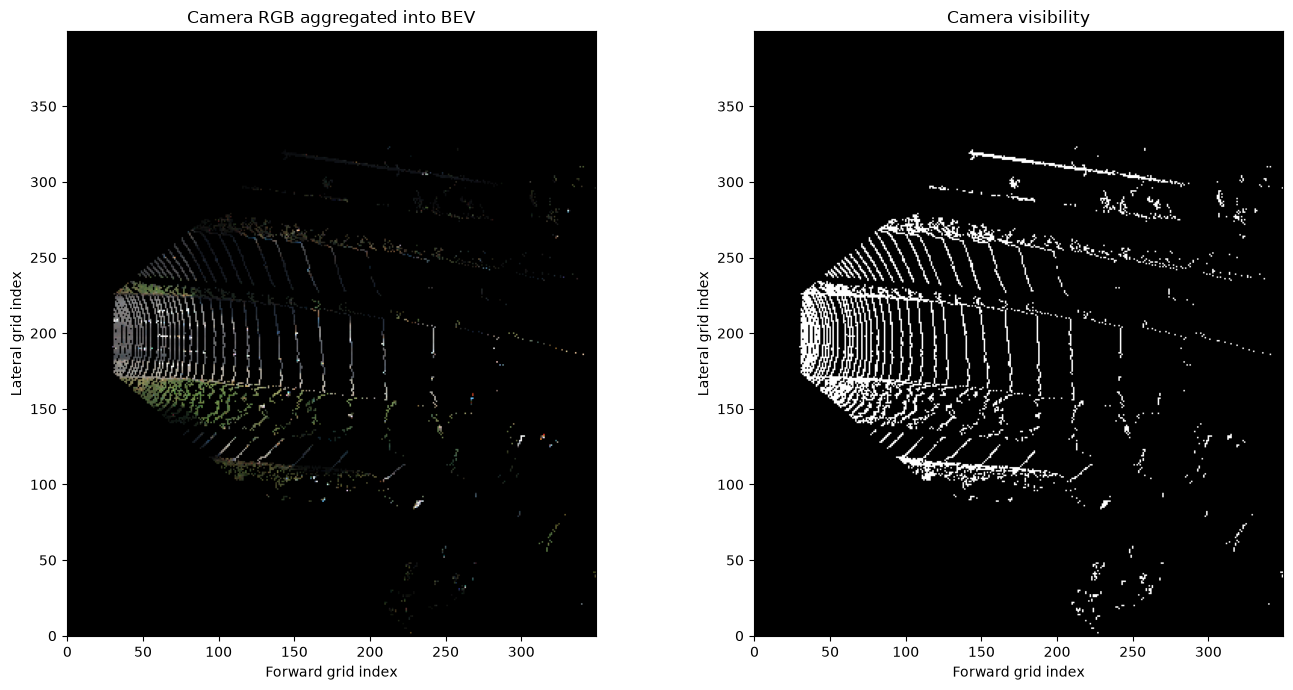

In [101]:
rgb_bev = np.transpose(
    camera_bev[:3],
    (2, 1, 0),
)

visibility = camera_bev[3].T

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 7),
)

axes[0].imshow(
    rgb_bev,
    origin="lower",
    aspect="equal",
)

axes[0].set_title("Camera RGB aggregated into BEV")
axes[0].set_xlabel("Forward grid index")
axes[0].set_ylabel("Lateral grid index")

axes[1].imshow(
    visibility,
    origin="lower",
    cmap="gray",
    aspect="equal",
)

axes[1].set_title("Camera visibility")
axes[1].set_xlabel("Forward grid index")
axes[1].set_ylabel("Lateral grid index")

fig.tight_layout()
plt.show()